In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import numpy as np
import quantecon as qe
import sys
from numpy.typing import NDArray
from scipy.linalg import expm
from scipy.spatial import KDTree
from scipy.special import logsumexp
from scipy.sparse import eye
from scipy.sparse.linalg import expm_multiply
from scipy.special import kl_div
from sklearn.manifold import MDS 
from sklearn.decomposition import PCA 
from tqdm.notebook import tqdm

In [2]:
MarkovChain = "P_matrix_cyclooctane_R144_MSM2.csv"
P_ref = np.loadtxt(f"MarkovChains/{MarkovChain}", delimiter=",")
P_ref = P_ref.astype("float64")

P_ref.shape

(2501, 2501)

$$\log_{kde}(p) = \psi(p) = \log\left(\sum_{i=1}^N c_i \exp(-KL(p \;||\; P_{i, -}))\right)$$

In [3]:
# Erik's log_kde computes KL divergence
# use P, and not R
class log_kde():
    def __init__(self, P, t):
        self.I = np.eye(P.shape[0])
        self.P = P
        self.Pt = expm(-t * (self.I - P))

    def compute_log_kde(self, p) -> NDArray:
        log_kde_sum = np.log(sum([np.exp(sum(-kl_div(p, row))) for row in self.Pt])) # need to sum kl_div, returns array
        return log_kde_sum

    def calculate_ti(self, p, i) -> np.floating:
        num = np.exp(sum(-kl_div(p, self.Pt[i])))
        den = sum(np.exp(sum(-kl_div(p, row_Pt))) for row_Pt in self.Pt)
        return num / den

    def calculate_q_i(self, t_i, i):
        r_i = t_i * np.log(self.Pt[i])

$$ \begin{align}
t_i &= \frac{\exp(-\mathrm{KL}(p \,\|\, P_i))}{\sum_j \exp(-\mathrm{KL}(p \,\|\, P_j))} \\[1mm]
&= \frac{\exp\Big(-H(p) + \sum_k p_k \log (P_i)_k\Big)}
       {\sum_j \exp\Big(-H(p) + \sum_k p_k \log (P_j)_k\Big)} \\[1mm]
&= \frac{\exp(-H(p)) \, \exp\Big(\sum_k p_k \log (P_i)_k\Big)}
       {\sum_j \exp(-H(p)) \, \exp\Big(\sum_k p_k \log (P_j)_k\Big)} \\[1mm]
&= \frac{\exp\Big(\sum_k p_k \log (P_i)_k\Big)}
       {\sum_j \exp\Big(\sum_k p_k \log (P_j)_k\Big)}
\end{align} $$

$$r = \sum_{i=1}^n t_i \log(P(t)_{i, -})$$

$$\tilde{q} = \exp(r)$$
$$\frac{\tilde{q}}{\sum_{i} \tilde{q}_i}$$
$$-\log(q_i)$$

$$T(p) = q$$
$$Q_{i, -} = T(P_{i, -})$$
$$\text{PCA}(\log{Q}) \rightarrow \text{Visualization}$$

In [ ]:
time = 500
log_kde_obj = log_kde(P_ref, t=time)

# stationary distribution
pi = qe.MarkovChain(P_ref).stationary_distributions

# build Q matrix
Q = []
R = []
for p_i in tqdm(log_kde_obj.Pt, dynamic_ncols=True):

    # construct t: using KL divergence in a different way
    logP = np.log(log_kde_obj.Pt)           # (n, d)
    scores = logP @ p_i + np.log(pi)        # (n,)
    t = np.exp(scores - logsumexp(scores))
    r = []
    # construct r
    for t_i, p_i in zip(t, log_kde_obj.Pt):
        r_i = t_i * np.log(p_i)             # scalar * log(array) = array
        r.append(r_i)
    r = sum(r)
    R.append(r)
    # construct q
    q_tilde = np.exp(r)
    q = q_tilde / q_tilde.sum()
    Q.append(q)

R_mat = np.vstack(R)
Q_mat = np.vstack(Q)

  0%|          | 0/2501 [00:00<?, ?it/s]

In [23]:
# projection generators
pca = PCA(n_components=3)
mds = MDS(n_components=3)

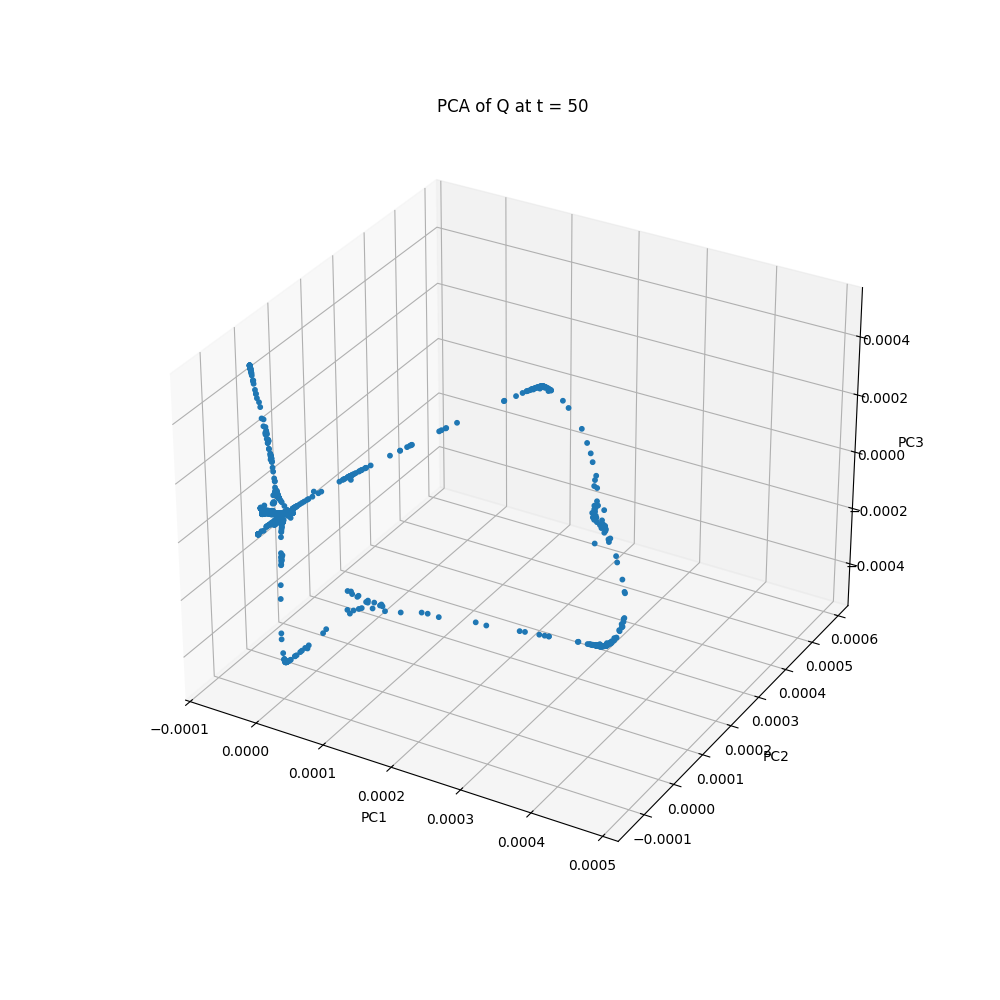

In [24]:
Q_proj_pca = pca.fit_transform(Q_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of Q at t = {time}")
# Scatter plot
sc = ax.scatter(
    Q_proj_pca[:, 0],
    Q_proj_pca[:, 1],
    Q_proj_pca[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)


# Optional: labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

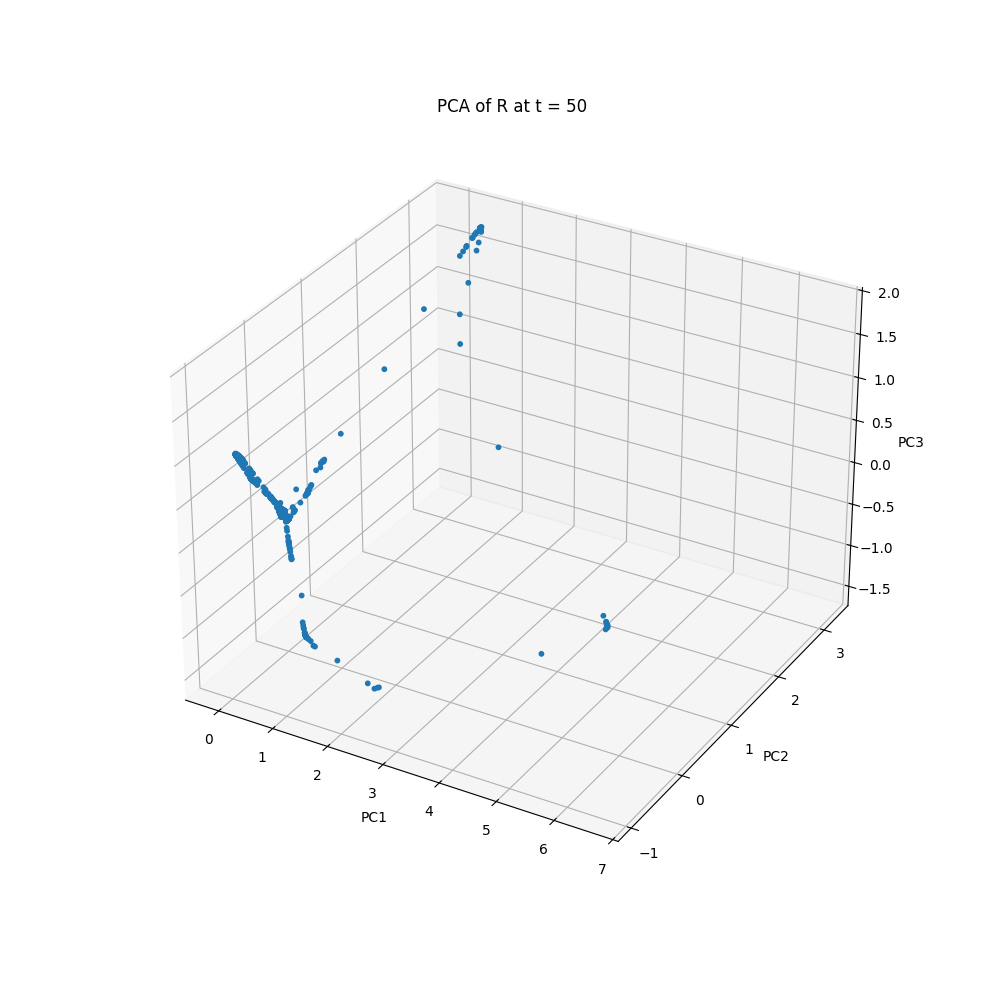

In [25]:
R_proj_pca = pca.fit_transform(R_mat)
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.set_title(f"PCA of R at t = {time}")
# Scatter plot
sc = ax.scatter(
    R_proj_pca[:, 0],
    R_proj_pca[:, 1],
    R_proj_pca[:, 2],
    s=10,
    alpha=1,
#    cmap='plasma',
#    c=shade
)

# labels
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
plt.show()

In [26]:
def sort_by_nearest_neighbor(points, start_idx=0):
    pts = np.array(points)
    tree = KDTree(pts)
    visited = [start_idx]
    remaining = set(range(len(pts))) - {start_idx}

    while remaining:
        last = visited[-1]
        # Query enough neighbors to find the nearest unvisited
        _, idxs = tree.query(pts[last], k=len(pts))
        for idx in idxs:
            if idx in remaining:
                visited.append(idx)
                remaining.remove(idx)
                break

    return visited

In [27]:
def parse_dump(dump_file):
    timesteps = []

    # read through dump_file
    with open(dump_file, 'r') as file:
        trajectory = file.readlines()

        current_timestep = ""
        counter = 0
        for line in trajectory:
            if line == "ITEM: TIMESTEP\n" and current_timestep:
                timesteps.append(current_timestep)
                counter += 1
                current_timestep = ""
            current_timestep += line

        timesteps.append(current_timestep)
    return timesteps

In [28]:
# takes NDarray
# needs a set of points
def gram_schmidt_orthonormalization(P):
    # Step 1: translate
    P_shifted = P - P[0]

    # Step 2: construct orthonormal frame
    p2 = P_shifted[1]
    p3 = P_shifted[2]
    z = np.cross(p2, p3)

    x_hat = p2 / np.linalg.norm(p2)
    z_hat = z / np.linalg.norm(z)
    y_hat = np.cross(z_hat, x_hat)

    # Rotation matrix
    R_mat = np.vstack([x_hat, y_hat, z_hat])

    # Apply rotation
    P_final = P_shifted @ R_mat.T

    return P_final.reshape(1, -1)

In [29]:
# rearrange and by NN PCA
alpha_conformations = sort_by_nearest_neighbor(R_proj_pca)
trajectories = parse_dump('trajectories/pos_cyclooctane.dump')
trajectories_reordered = [trajectories[i] for i in alpha_conformations]

In [30]:
with open("pos_cyclooctane_reordered.dump", "w") as file:
    file.writelines(trajectories_reordered)

In [31]:
with open("alpha_movie.dump", "w") as alpha_movie:
    for traj in parse_dump("pos_cyclooctane_reordered.dump"):
        # step information
        timestep = 0
        num_atoms = -1
        pos_atoms = []
        type_atoms = []
        grab_pos = False

        traj = traj.split("\n")
        for i, line in enumerate(traj):
            # grabs atom type and xyz
            if grab_pos and line:
                type_atoms.append(line.split(" ")[-4])
                pos_atoms.append(line.split(" ")[-3:])

            # grabs timestep
            elif line == "ITEM: TIMESTEP":
                timestep = traj[i + 1]

            # grabs number of atoms
            elif line == "ITEM: NUMBER OF ATOMS":
                num_atoms = traj[i + 1]

            # enables position grabbing, positions are always last lines in a timestep
            elif "ITEM: ATOMS" in line:
                grab_pos = True
            
        positions = np.array(pos_atoms, dtype=np.float64)
        shifted_positions = gram_schmidt_orthonormalization(positions).reshape(-1, 3)
        # write to file
        alpha_movie.write(f"{num_atoms}\n")
        alpha_movie.write(f"timestep {timestep}\n")
        for type, pos in zip(type_atoms, shifted_positions):
            alpha_movie.write(f"{type} {" ".join(map(str, pos))}\n")

In [32]:
shifted_positions = gram_schmidt_orthonormalization(positions).reshape(-1, 3)
for type, pos in zip(type_atoms, shifted_positions):
    print(type, " ".join(map(str, pos)))

2 0.0 0.0 0.0
2 1.6133982317866722 7.638700098118492e-17 6.699384303585377e-17
2 2.2194296298117093 1.4498360755108899 9.717752236538977e-17
2 1.72172822841314 2.4887732377427043 -0.8892929530461849
2 0.6251683084769402 3.5850517780191162 -0.542562300725199
2 -0.7874001556188731 3.0263291021617853 -0.2590928289177038
2 -0.9703723262563037 2.151766083582518 1.1560088683237868
2 -0.7421493433091609 0.6088024352924057 1.0992398277296804
1 -0.29029708101339263 -0.9735017584679109 0.2830670906992705
1 -0.25588162309553514 0.3921863830212245 -0.9225612328172499
1 2.004935187263964 -0.56666083696384 0.9153153188803372
1 2.113736937278284 -0.7372073940562469 -0.7989569835715654
1 2.1743295075517386 1.70234816862273 1.0661150832909239
1 3.215407779493771 1.0067655145905121 -0.35007773092071665
1 2.603319546473335 3.112989007307784 -1.3130277152089842
1 1.3101262085596772 2.0950719000689686 -1.880287475509584
1 0.7890239675629448 4.3695560803189455 0.21537607292436603
1 0.5696000901518721 4.1584

In [33]:
# returns the points closest to each other on Alpha shape
alpha_conformations = sort_by_nearest_neighbor(R_proj_pca)

# reorder pos.dump with this ordering


In [34]:
# extract new basis vectors for each frame
# take the average(0, 1) to average(4, 5) = a
# take the average(2, 3) to average(6, 7) = b

def generate_basis_vectors(carbons):
    # x basis vector
    midpoint_p0p1 = (carbons[0] + carbons[1]) / 2
    midpoint_p4p5 = (carbons[4] + carbons[5]) / 2
    a = midpoint_p4p5 - midpoint_p0p1

    # y basis vector
    midpoint_p2p3 = (carbons[2] + carbons[3]) / 2
    midopint_p6p7 = (carbons[6] + carbons[7]) / 2
    b = midopint_p6p7 - midpoint_p2p3

    return a, b
print(positions[0:8])

[[ 1.68353    0.384018   0.0305574]
 [ 0.925191   1.74781    0.440493 ]
 [-0.639315   1.60395    0.410096 ]
 [-1.32903    0.965657  -0.701126 ]
 [-1.77862   -0.555867  -0.786718 ]
 [-0.619413  -1.57756   -0.802786 ]
 [ 0.249094  -1.73837    0.618723 ]
 [ 1.50325   -0.831052   0.818503 ]]


In [35]:
# builds a new basis
def build_rotation_matrix(a, b):
    """Build rotation matrix from two new axis directions (x, y), leave z free."""
    u1 = a / np.linalg.norm(a)

    # Gram-Schmidt: remove u1 component from b
    u2 = b - np.dot(b, u1) * u1
    u2 = u2 / np.linalg.norm(u2)

    # Stack as rows; z row passes through
    R = np.array([
        [u1[0], u1[1], u1[2]],
        [u2[0], u2[1], u2[2]],
        [0,     0,     1    ],
    ])
    return R

In [36]:
# transforms the points
def transform_points(points, a, b, origin=None):
    """
    points: (N, 3) array
    a, b:   new x and y axis directions (3D vectors)
    origin: optional point to subtract before rotating
    """
    R = build_rotation_matrix(a, b)
    if origin is not None:
        points = points - origin
    return (R @ points.T).T

In [37]:
with open("alpha_movie_rotated.dump", "w") as alpha_movie:
    for traj in parse_dump("pos_cyclooctane_reordered.dump"):
        # step information
        timestep = 0
        num_atoms = -1
        pos_atoms = []
        type_atoms = []
        grab_pos = False

        traj = traj.split("\n")
        for i, line in enumerate(traj):
            # grabs atom type and xyz
            if grab_pos and line:
                type_atoms.append(line.split(" ")[-4])
                pos_atoms.append(line.split(" ")[-3:])

            # grabs timestep
            elif line == "ITEM: TIMESTEP":
                timestep = traj[i + 1]

            # grabs number of atoms
            elif line == "ITEM: NUMBER OF ATOMS":
                num_atoms = traj[i + 1]

            # enables position grabbing, positions are always last lines in a timestep
            elif "ITEM: ATOMS" in line:
                grab_pos = True

        # rotation operations 
        positions = np.array(pos_atoms, dtype=np.float64)
        carbons = positions[0:8]
        a, b = generate_basis_vectors(carbons)
        rotation_matrix = build_rotation_matrix(a, b)

        rotated_positions = (rotation_matrix @ positions.T).T
        # write to file
        alpha_movie.write(f"{num_atoms}\n")
        alpha_movie.write(f"timestep {timestep}\n")
        for type, pos in zip(type_atoms, rotated_positions):
            alpha_movie.write(f"{type} {" ".join(map(str, pos))}\n")